In [1]:
import pandas as pd

In [2]:
# Load the NYPD complaint data
df = pd.read_csv('CCRB-Complaint-Data_202007271729/allegations_202007271729.csv')

# Display basic info
print(f"Total complaints: {len(df)}")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Total complaints: 33358

Dataset shape: (33358, 27)

Column names:
['unique_mos_id', 'first_name', 'last_name', 'command_now', 'shield_no', 'complaint_id', 'month_received', 'year_received', 'month_closed', 'year_closed', 'command_at_incident', 'rank_abbrev_incident', 'rank_abbrev_now', 'rank_now', 'rank_incident', 'mos_ethnicity', 'mos_gender', 'mos_age_incident', 'complainant_ethnicity', 'complainant_gender', 'complainant_age_incident', 'fado_type', 'allegation', 'precinct', 'contact_reason', 'outcome_description', 'board_disposition']

First few rows:


,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,...,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges)
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,...,39,NaN,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A)


In [7]:
# Data Cleaning: Categorize consequences
serious_outcomes = {
    'Substantiated (Charges)',
    'Substantiated (CCRB Rec. DOE)',
    'Substantiated (CCRB Rec. Hrd)',
    'Substantiated (CCRB Rec. HOD)'
}

df['consequence'] = 'No Serious Discipline'
df.loc[df['board_disposition'].isin(serious_outcomes), 'consequence'] = 'Serious Discipline'

counts = df['consequence'].value_counts().reindex(
    ['Serious Discipline', 'No Serious Discipline'],
    fill_value=0
)

print(counts)

Data cleaned. Serious: 3,796 | No Serious: 29,562


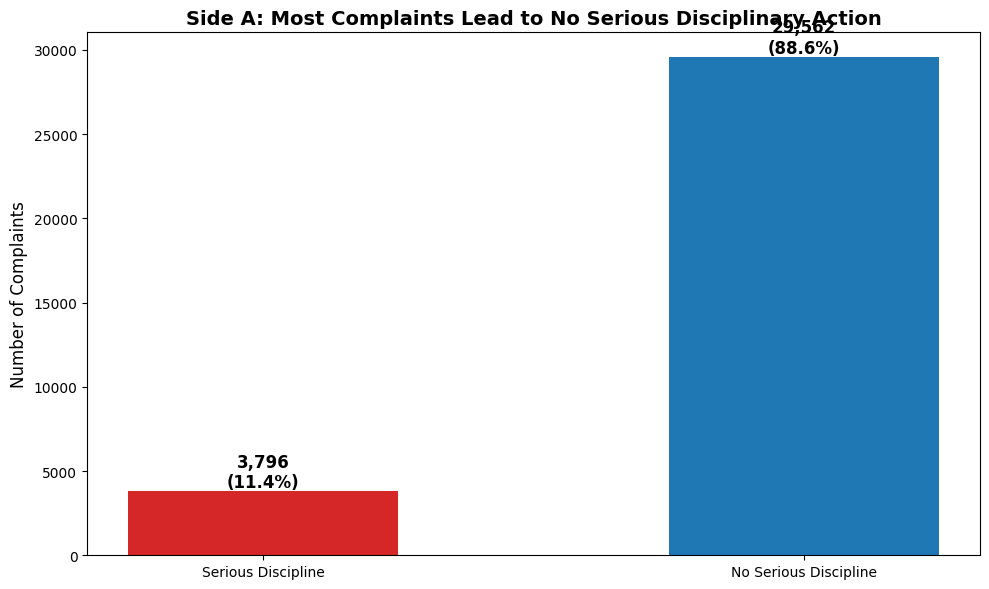

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    counts.index,
    counts.values,
    color=['#d62728', '#1f77b4'],
    width=0.5
)

ax.set_ylabel('Number of Complaints', fontsize=12)
ax.set_title(
    'Side A: Most Complaints Lead to No Serious Disciplinary Action',
    fontsize=14,
    fontweight='bold'
)

for bar in bars:
    count = bar.get_height()
    pct = count / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        f'{int(count):,}\n({pct:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()